# Picture Naming: image vs sound on frozen NMF clusters

Exploratory. Does **not** change `vizpub/fig2.ipynb`.

Canonical concat-NMF was fit on Repeat + `sound` (PhonemeSequence, LexicalDelay,
PictureNaming, SentenceRep). Picture Naming also shows the same four concepts
(apple, duck, star, umbrella) as pictures. This notebook holds the NMF hard
labels fixed and asks whether those clusters generalize across modality.

| cluster key | display here | expected picture response |
|---|---|---|
| `sensory` | sensory | largely silent (brief auditory) |
| `sustain` | sustain | responds |
| `motor` | motor | similar at response in both; not the stimulus dissociation |

`sustain` in `channel_assignments.csv` is the AIC-weighted component; this
notebook labels it **scene** in titles only. Colors still come from
`FUNCTION_COLORS`. Mixed electrodes stay in (hard argmax, no drop).

**Why zscore epochs, not packaged HGA.** Packaged PictureNaming CSVs keep the
subject × modality significance union. An NMF sensory electrode that is
silent to pictures would be missing from the image CSVs, which would bias the
image mean toward responders. Here we `.pick` the frozen NMF channels from
`epoch(band)(zscore)` in **both** image and sound.

Other caveats:

- The electrode set is still the sound-derived NMF union (Aim 1.1
  domain-generality among auditory-selected insula contacts).
- PN baseline is condition-start `StartCue`, not re-estimated per modality.
  Prefer shape and paired image−sound differences over absolute height.
- Text is excluded (insufficient responses).
- About 133 of 255 assigned electrodes are in PN subjects (sensory 19 /
  scene 49 / motor 65 before epoch overlap).

Load cell is heavy. Run on a compute node in `ieeg`, not the login node.
SVG only, under `img/picture_naming_modality/`.


In [7]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from IPython.display import display
from matplotlib.lines import Line2D
from mne_bids import BIDSPath
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.connectivity.pairwise.config import DEFAULT_DATASETS
from src.nmf.waveform_analysis import FUNCTION_COLORS
from src.paths import hga_results_dir, img_dir, nmf_assignments_path, save_svg

warnings.filterwarnings("ignore", message="This filename")


In [8]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

fontsize = 7
fontdict = dict(fontsize=fontsize)

# Hypothesis order: sensory should fail on pictures; scene/AIC should not.
CLUSTERS = ["sensory", "sustain", "motor"]
DISPLAY_LABELS = {
    "sensory": "sensory",
    "sustain": "scene",
    "motor": "motor",
}

TASK = "PictureNaming"
BIDS_ROOT = DEFAULT_DATASETS[TASK]
REF = "bipolar"
BAND = "highgamma"
DESCRIPTIONS = ["Repeat", "Passive"]
MODALITIES = ["sound", "image"]
PHASES = ["stimulus", "delay", "response"]
EXCLUDE_SUBJECTS = {"D0121"}
TIME_MAX = 1.5
STIM_WINDOW = (0.0, 0.5)

TRACE_XLIMS = {
    "stimulus": (-0.5, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 1.0),
}
TRACE_XTICKS = {
    "stimulus": (-0.5, 0.0, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 0.0, 1.0),
}
MODALITY_LINESTYLES = {
    "sound": "-",
    "image": (0, (3.5, 1.6)),
}
CLUSTER_CMAPS = {
    name: sns.light_palette(color, as_cmap=True)
    for name, color in FUNCTION_COLORS.items()
}
HEATMAP_MARGINS = dict(left=0.16, right=0.94, wspace=0.2, hspace=0.42)
HEATMAP_VMAX_Q = 0.95

NMF_ASSIGNMENTS = nmf_assignments_path()
IMG_DIR = img_dir("picture_naming_modality")


def _norm_phase(phase: str) -> str:
    p = str(phase)
    if p == "Resp":
        p = "Response"
    elif p == "Audio":
        p = "Stimulus"
    return p.lower()


def _norm_subject(subject: str) -> str:
    return str(subject).removeprefix("sub-")


def _modality_of(path) -> str:
    return path.recording if path.recording is not None else "sound"


def epoch_root(bids_root: str) -> str:
    return str(Path(bids_root) / f"derivatives/epoch({REF})")


def style_ax(ax, *, ylim=None):
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if ylim is not None:
        ax.set_ylim(*ylim)


def save_panel(fig, name: str, *, aligned: bool = False) -> Path:
    out = IMG_DIR / name
    if aligned:
        out = out.with_suffix(".svg")
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, format="svg", bbox_inches=None, pad_inches=0, dpi=300)
        return out
    return save_svg(fig, out, close=False)


In [9]:
def n_label(df: pd.DataFrame) -> str:
    counts = [int(df.loc[df.modality == m, "channel"].nunique()) for m in MODALITIES]
    if len(set(counts)) <= 1:
        return f"n={counts[0] if counts else 0}"
    return ", ".join(
        f"n_{m}={c}" for m, c in zip(MODALITIES, counts)
    )


def list_zscore_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype="epoch(band)(zscore)",
        suffix=BAND,
        extension=".h5",
        check=False,
    ).match()


def evoked_to_long(epochs, channels: list[str]) -> pd.DataFrame | None:
    picks = [ch for ch in channels if ch in epochs.ch_names]
    if not picks:
        return None
    epo = epochs.copy().pick(picks, verbose=False)
    data = np.nanmean(epo.get_data(copy=False), axis=0)
    times = epo.times
    n_ch, n_t = data.shape
    return pd.DataFrame(
        {
            "time": np.tile(times, n_ch),
            "channel": np.repeat(list(epo.ch_names), n_t),
            "value": data.reshape(-1),
        }
    )


def load_assignments() -> pd.DataFrame:
    meta = pd.read_csv(NMF_ASSIGNMENTS)
    required = {"subject", "channel", "functional_cluster"}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f"{NMF_ASSIGNMENTS} missing columns: {sorted(missing)}")
    meta = meta.copy()
    meta["subject"] = meta["subject"].map(_norm_subject)
    meta = meta[meta["functional_cluster"].isin(CLUSTERS)].copy()
    meta = meta[~meta["subject"].isin(EXCLUDE_SUBJECTS)]
    return meta.drop_duplicates(subset=["subject", "channel"], keep="first").reset_index(
        drop=True
    )


def load_picture_naming(assignments: pd.DataFrame) -> pd.DataFrame:
    """Trial-average PN zscore epochs for frozen NMF channels.

    Same assignment channels are picked in image and sound. This does not use
    the packaged image significance union, so silent sensory electrodes remain.
    """
    assign_by_subj = {
        subj: sorted(g["channel"]) for subj, g in assignments.groupby("subject")
    }
    clustered = assignments.set_index(["subject", "channel"])
    channel_cluster = clustered["functional_cluster"].to_dict()
    channel_roi = clustered["roi"].to_dict() if "roi" in clustered.columns else {}
    channel_hemi = clustered["hemi"].to_dict() if "hemi" in clustered.columns else {}
    xyz = {}
    if {"x", "y", "z"}.issubset(clustered.columns):
        xyz = clustered[["x", "y", "z"]].to_dict("index")

    desc_set = set(DESCRIPTIONS)
    mod_set = set(MODALITIES)
    phase_set = set(PHASES)
    rows = []
    n_empty = 0
    for path in tqdm(list_zscore_paths(BIDS_ROOT), desc="PN zscore"):
        if path.description not in desc_set:
            continue
        modality = _modality_of(path)
        if modality not in mod_set:
            continue
        phase = _norm_phase(path.processing)
        if phase not in phase_set:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        picks = assign_by_subj.get(subj)
        if not picks:
            continue
        epochs = mne.read_epochs(path, preload=True, verbose=False)
        df = evoked_to_long(epochs, picks)
        del epochs
        if df is None or df.empty:
            n_empty += 1
            continue
        df["subject"] = subj
        df["description"] = path.description
        df["task"] = TASK
        df["phase"] = phase
        df["modality"] = modality
        keys = list(zip([subj] * len(df), df["channel"]))
        df["functional_cluster"] = [channel_cluster.get(k) for k in keys]
        df["roi"] = [channel_roi.get(k) for k in keys]
        df["hemi"] = [channel_hemi.get(k) for k in keys]
        if xyz:
            df["x"] = [xyz[k]["x"] if k in xyz else np.nan for k in keys]
            df["y"] = [xyz[k]["y"] if k in xyz else np.nan for k in keys]
            df["z"] = [xyz[k]["z"] if k in xyz else np.nan for k in keys]
        rows.append(df)

    if not rows:
        raise FileNotFoundError(f"No PN zscore rows for NMF channels under {BIDS_ROOT}")
    out = pd.concat(rows, ignore_index=True)
    out = out[out["functional_cluster"].isin(CLUSTERS) & (out["time"] < TIME_MAX)].copy()
    out["cluster_label"] = out["functional_cluster"].map(DISPLAY_LABELS)
    print("empty pick files:", n_empty)
    return out


def window_means(df: pd.DataFrame, phase: str = "stimulus", window=STIM_WINDOW) -> pd.DataFrame:
    lo, hi = window
    sub = df[(df.phase == phase) & (df.time >= lo) & (df.time < hi)]
    out = (
        sub.groupby(
            ["channel", "subject", "functional_cluster", "modality"],
            as_index=False,
        )["value"]
        .mean()
        .rename(columns={"value": "hga"})
    )
    extra_cols = [c for c in ("roi", "hemi", "x", "y", "z") if c in df.columns]
    if extra_cols:
        extra = df.drop_duplicates("channel")[["channel", *extra_cols]]
        out = out.merge(extra, on="channel", how="left")
    return out


def paired_modalities(means: pd.DataFrame) -> pd.DataFrame:
    index_cols = ["channel", "subject", "functional_cluster"]
    wide = means.pivot_table(
        index=index_cols,
        columns="modality",
        values="hga",
    ).dropna(subset=MODALITIES)
    wide = wide.reset_index()
    wide["delta"] = wide["image"] - wide["sound"]
    wide["cluster_label"] = wide["functional_cluster"].map(DISPLAY_LABELS)
    return wide


def attach_packaged_mask(df: pd.DataFrame) -> pd.DataFrame:
    """Add the packaged PictureNaming stats `mask` without reloading zscore epochs.

    Packaged CSVs are the subject × modality significance union, so a silent
    image contact is simply `mask` False rather than dropped from the zscore
    table. Missing matches are treated as not significant.
    """
    wanted_subj = set(df["subject"].map(_norm_subject))
    wanted_desc = set(df["description"].astype(str))
    wanted_mod = set(df["modality"].astype(str))
    wanted_phase = set(df["phase"].map(_norm_phase))
    paths = BIDSPath(
        root=str(hga_results_dir(TASK)),
        datatype="HGA",
        suffix="time",
        check=False,
    ).match()
    frames = []
    for path in tqdm(paths, desc="PN packaged mask"):
        desc = path.description
        mod = path.recording if path.recording is not None else "sound"
        phase = _norm_phase(path.processing)
        subj = _norm_subject(path.subject)
        if (
            subj not in wanted_subj
            or desc not in wanted_desc
            or mod not in wanted_mod
            or phase not in wanted_phase
        ):
            continue
        frame = pd.read_csv(
            path,
            usecols=[
                "channel",
                "time",
                "mask",
                "subject",
                "phase",
                "modality",
                "description",
            ],
        )
        if frame.empty:
            continue
        frame["subject"] = frame["subject"].map(_norm_subject)
        frame["phase"] = frame["phase"].map(_norm_phase)
        frame["time"] = np.round(frame["time"].to_numpy(dtype=float), 4)
        frames.append(frame)
    out = df.drop(columns=["mask"], errors="ignore").copy()
    out["time"] = np.round(out["time"].to_numpy(dtype=float), 4)
    if not frames:
        out["mask"] = False
        print("no packaged HGA mask files matched; heatmap will be blank")
        return out
    mask_df = pd.concat(frames, ignore_index=True).drop_duplicates(
        subset=["subject", "channel", "time", "phase", "modality", "description"],
        keep="first",
    )
    out = out.merge(
        mask_df,
        on=["subject", "channel", "time", "phase", "modality", "description"],
        how="left",
    )
    out["mask"] = out["mask"].fillna(False).astype(bool)
    print(
        "mask True fraction",
        round(float(out["mask"].mean()), 3),
        "|",
        "channels with any sig",
        int(out.loc[out["mask"], "channel"].nunique()),
        "/",
        int(out["channel"].nunique()),
    )
    return out


## Load frozen assignments and Picture Naming zscore epochs

Repeat and Passive × image and sound × stimulus / delay / response. Text and
go are skipped. Same NMF channels in every curve.


In [10]:
assignments = load_assignments()
print(
    "NMF assignments:",
    len(assignments),
    "| subjects",
    assignments.subject.nunique(),
    "|",
    assignments["functional_cluster"].value_counts().reindex(CLUSTERS).to_dict(),
)
print("assignments:", NMF_ASSIGNMENTS)
print("BIDS:", BIDS_ROOT)

HGAs = load_picture_naming(assignments)
repeat = HGAs[HGAs.description == "Repeat"].copy()
passive = HGAs[HGAs.description == "Passive"].copy()

print(
    "rows",
    len(HGAs),
    "| channels",
    HGAs.channel.nunique(),
    "| subjects",
    HGAs.subject.nunique(),
)
print("descriptions", sorted(HGAs.description.unique()))
print("modalities", sorted(HGAs.modality.unique()))
print("phases", sorted(HGAs.phase.unique()))

cov = (
    repeat.groupby(["functional_cluster", "modality"])["channel"]
    .nunique()
    .unstack("modality")
    .reindex(index=CLUSTERS, columns=MODALITIES)
)
print("Repeat unique channels by cluster × modality")
display(cov)

paired_n = (
    repeat.groupby(["channel", "functional_cluster"])["modality"]
    .nunique()
    .reset_index(name="n_mod")
)
paired_n = paired_n[paired_n.n_mod == 2]
print(
    "paired image+sound Repeat channels:",
    paired_n.groupby("functional_cluster").size().reindex(CLUSTERS).to_dict(),
)
display(repeat.head())


NMF assignments: 255 | subjects 63 | {'sensory': 39, 'sustain': 80, 'motor': 136}
assignments: /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/channel_assignments.csv
BIDS: /cwork/ns458/BIDS-1.3_PictureNaming/BIDS


PN zscore:   0%|          | 0/888 [00:00<?, ?it/s]

empty pick files: 0
rows 510720 | channels 133 | subjects 27
descriptions ['Passive', 'Repeat']
modalities ['image', 'sound']
phases ['delay', 'response', 'stimulus']
Repeat unique channels by cluster × modality


modality,sound,image
functional_cluster,,
sensory,19,19
sustain,49,49
motor,65,65


paired image+sound Repeat channels: {'sensory': 19, 'sustain': 49, 'motor': 65}


,time,channel,value,subject,description,task,phase,modality,functional_cluster,roi,hemi,x,y,z,cluster_label
3520,-1.000000,D0079_LAI1-2,-0.192238,D0079,Repeat,PictureNaming,delay,image,sustain,AIC,L,-30.6433,26.04074,-34.8076,scene
3521,-0.992188,D0079_LAI1-2,-0.126247,D0079,Repeat,PictureNaming,delay,image,sustain,AIC,L,-30.6433,26.04074,-34.8076,scene
3522,-0.984375,D0079_LAI1-2,-0.058855,D0079,Repeat,PictureNaming,delay,image,sustain,AIC,L,-30.6433,26.04074,-34.8076,scene
3523,-0.976562,D0079_LAI1-2,-0.041374,D0079,Repeat,PictureNaming,delay,image,sustain,AIC,L,-30.6433,26.04074,-34.8076,scene
3524,-0.968750,D0079_LAI1-2,-0.073887,D0079,Repeat,PictureNaming,delay,image,sustain,AIC,L,-30.6433,26.04074,-34.8076,scene


## Repeat traces: cluster × phase, sound vs image

Solid = sound, dashed = image. Color is the frozen NMF cluster. The stimulus
column is the test: sensory should lose the early peak on pictures; scene
should keep a response; motor should not carry the dissociation.


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_cluster_phase_image_sound.svg


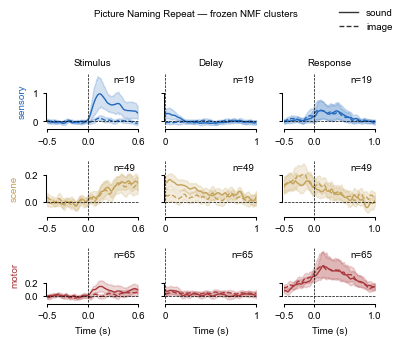

In [11]:
def plot_cluster_phase_grid(df: pd.DataFrame, name: str, title: str):
    n_rows, n_cols = len(CLUSTERS), len(PHASES)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.4 * n_cols * cm, 2.8 * n_rows * cm),
        sharey="row",
    )
    for i, cluster in enumerate(CLUSTERS):
        color = FUNCTION_COLORS[cluster]
        for j, phase in enumerate(PHASES):
            ax = axes[i, j]
            lo, hi = TRACE_XLIMS[phase]
            phase_df = df[
                (df.functional_cluster == cluster)
                & (df.phase == phase)
                & (df.time >= lo)
                & (df.time <= hi)
            ]
            for modality in MODALITIES:
                sns.lineplot(
                    data=phase_df[phase_df.modality == modality],
                    x="time",
                    y="value",
                    ax=ax,
                    color=color,
                    linestyle=MODALITY_LINESTYLES[modality],
                    lw=1,
                    errorbar=("ci", 95),
                    legend=False,
                )
            ax.set_xlim(lo, hi)
            ax.set_xticks(TRACE_XTICKS[phase])
            ax.set_xlabel("Time (s)" if i == n_rows - 1 else "", fontsize=fontsize)
            if i == 0:
                ax.set_title(phase.capitalize(), fontsize=fontsize)
            ax.set_ylabel(
                DISPLAY_LABELS[cluster] if j == 0 else "",
                fontsize=fontsize,
                color=color,
            )
            style_ax(ax)
            ax.text(
                0.97,
                0.96,
                n_label(phase_df),
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=fontsize,
            )
    handles = [
        Line2D(
            [0],
            [0],
            color="0.2",
            lw=1,
            linestyle=MODALITY_LINESTYLES[modality],
            label=modality,
        )
        for modality in MODALITIES
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=fontsize, frameon=False)
    fig.suptitle(title, fontsize=fontsize, y=1.03)
    fig.tight_layout()
    out = save_panel(fig, name)
    print("wrote", out)
    plt.show()


plot_cluster_phase_grid(
    repeat,
    "pn_repeat_cluster_phase_image_sound.svg",
    "Picture Naming Repeat — frozen NMF clusters",
)


## Repeat heatmap: channel × time

Sternberg load layout: **one row of axes per cluster**, three phases. Sound (top)
and image (bottom) share the same `pcolormesh`; a dashed line marks the split.
No extra axis between modalities.

Stimulus/delay column widths follow Figure 2; response is cropped at 1.0 s.
8 cm canvas, no tight crop.


PN packaged mask:   0%|          | 0/888 [00:00<?, ?it/s]

mask True fraction 0.103 | channels with any sig 113 / 133
cluster vmax (sig 95th pct) {'sensory': 2.084, 'sustain': 0.741, 'motor': 1.453}
channels with any sig {'sensory': 16, 'sustain': 39, 'motor': 57}
wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_cluster_phase_heatmap.svg


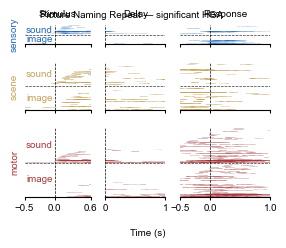

In [12]:
def heatmap_channel_order(
    df: pd.DataFrame, cluster: str, phases=None
) -> list[str]:
    """One row identity for the requested phases: sig in any crop, sorted by first sig."""
    phases = tuple(PHASES if phases is None else phases)
    phase_rank = {phase: i for i, phase in enumerate(phases)}
    parts = []
    for phase in phases:
        lo, hi = TRACE_XLIMS[phase]
        parts.append(
            df[
                (df.functional_cluster == cluster)
                & (df.phase == phase)
                & (df.time >= lo)
                & (df.time <= hi)
            ]
        )
    cluster_data = pd.concat(parts, ignore_index=True)
    first_sig = []
    for ch in sorted(cluster_data["channel"].unique()):
        sig = cluster_data.loc[
            (cluster_data.channel == ch) & cluster_data["mask"],
            ["phase", "time"],
        ]
        if sig.empty:
            continue
        sig = sig.copy()
        sig["rank"] = sig["phase"].map(phase_rank)
        row = sig.sort_values(["rank", "time"]).iloc[0]
        first_sig.append((ch, float(row["rank"]), float(row["time"])))
    return [ch for ch, _, _ in sorted(first_sig, key=lambda x: (x[1], x[2], x[0]))]


def cluster_vmax(df: pd.DataFrame, cluster: str, q: float = HEATMAP_VMAX_Q) -> float:
    vals = df.loc[df.functional_cluster == cluster, "value"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return 1.0
    return max(float(np.quantile(vals, q)), 0.15)


def modality_pivot(phase_data: pd.DataFrame, ordered: list[str], modality: str) -> pd.DataFrame:
    sub = phase_data[phase_data.modality == modality]
    if sub.empty:
        return pd.DataFrame(index=ordered)
    return (
        sub.pivot_table(index="channel", columns="time", values="value", aggfunc="mean")
        .reindex(index=ordered)
    )


def heatmap_figure_width(phases, ref_width: float = 8 * cm) -> float:
    """Keep each phase as wide as in the full stimulus / delay / response layout."""
    left = HEATMAP_MARGINS["left"]
    right = HEATMAP_MARGINS["right"]
    wspace = HEATMAP_MARGINS["wspace"]
    span = right - left

    def axis_fracs(phase_list):
        n = len(phase_list)
        ratios = [TRACE_XLIMS[p][1] - TRACE_XLIMS[p][0] for p in phase_list]
        avg = span / (n + max(n - 1, 0) * wspace)
        total = sum(ratios)
        return {
            phase: avg * n * ratio / total
            for phase, ratio in zip(phase_list, ratios)
        }

    ref = axis_fracs(PHASES)
    req = axis_fracs(phases)
    key = "stimulus" if "stimulus" in phases else phases[0]
    return ref_width * ref[key] / req[key]


def plot_cluster_phase_heatmap(df: pd.DataFrame, name: str, title: str, phases=None):
    phases = tuple(PHASES if phases is None else phases)
    df = attach_packaged_mask(df)
    df = df.copy()
    df.loc[~df["mask"], "value"] = np.nan

    ordered_by_cluster = {
        cluster: heatmap_channel_order(df, cluster, phases=phases) for cluster in CLUSTERS
    }
    n_by_cluster = {
        cluster: max(len(ordered_by_cluster[cluster]), 1) for cluster in CLUSTERS
    }
    vmax_by_cluster = {cluster: cluster_vmax(df, cluster) for cluster in CLUSTERS}
    # Sound (top) + image (bottom) in one axis, like Sternberg loads.
    height_ratios = [2 * n_by_cluster[cluster] for cluster in CLUSTERS]
    width_ratios = [hi - lo for lo, hi in (TRACE_XLIMS[p] for p in phases)]

    fig = plt.figure(
        figsize=(heatmap_figure_width(phases), 0.02 * sum(height_ratios) * cm + 1.4 * cm),
    )
    gs = fig.add_gridspec(
        nrows=len(CLUSTERS),
        ncols=len(phases),
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        hspace=HEATMAP_MARGINS["hspace"],
        wspace=HEATMAP_MARGINS["wspace"],
        left=HEATMAP_MARGINS["left"],
        right=HEATMAP_MARGINS["right"],
        bottom=0.18,
        top=0.92,
    )
    axes = np.empty((len(CLUSTERS), len(phases)), dtype=object)
    for i in range(len(CLUSTERS)):
        for j in range(len(phases)):
            sharex = axes[0, j] if i > 0 else None
            axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

    for i, cluster in enumerate(CLUSTERS):
        cmap = CLUSTER_CMAPS[cluster].copy()
        cmap.set_bad(color="white")
        vmax = vmax_by_cluster[cluster]
        ordered = ordered_by_cluster[cluster]
        n = len(ordered)
        for j, phase in enumerate(phases):
            ax = axes[i, j]
            lo, hi = TRACE_XLIMS[phase]
            phase_data = df[
                (df.phase == phase)
                & (df.functional_cluster == cluster)
                & df.channel.isin(ordered)
                & (df.time >= lo)
                & (df.time <= hi)
            ]
            if not ordered:
                ax.text(
                    0.5,
                    0.5,
                    "No significant\nchannels",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=fontsize,
                )
            else:
                pivots = {
                    modality: modality_pivot(phase_data, ordered, modality)
                    for modality in MODALITIES
                }
                times = sorted(
                    {
                        float(t)
                        for pivot in pivots.values()
                        for t in pivot.columns
                    }
                )
                for modality, pivot in pivots.items():
                    pivots[modality] = pivot.reindex(columns=times)
                # Image at y=0 (bottom), sound on top — matches previous top-to-bottom order.
                stacked = pd.concat(
                    [pivots["image"], pivots["sound"]],
                    axis=0,
                )
                if stacked.empty or stacked.shape[1] == 0:
                    ax.text(
                        0.5,
                        0.5,
                        "No samples",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                        fontsize=fontsize,
                    )
                else:
                    da = xr.DataArray(
                        stacked.to_numpy(dtype=float),
                        coords={
                            "channel": np.arange(len(stacked)),
                            "time": stacked.columns.astype(float),
                        },
                        dims=["channel", "time"],
                    )
                    time_values = da.coords["time"].values.astype(float)
                    step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
                    time_edges = np.concatenate(
                        (
                            [time_values[0] - step / 2],
                            time_values[:-1] + step / 2,
                            [time_values[-1] + step / 2],
                        )
                    )
                    channel_edges = np.arange(len(stacked) + 1)
                    T, C = np.meshgrid(time_edges, channel_edges)
                    ax.pcolormesh(
                        T,
                        C,
                        da.values,
                        cmap=cmap,
                        vmin=0,
                        vmax=vmax,
                        shading="auto",
                        rasterized=True,
                    )
                    ax.axhline(
                        y=n,
                        color="k",
                        linestyle="--",
                        linewidth=0.5,
                        alpha=0.8,
                        zorder=10,
                    )

            ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
            ax.set_xlim(lo, hi)
            ax.set_ylim(0, max(2 * n, 1))
            ax.set_yticks([])
            ax.tick_params(
                axis="y", which="both", left=False, right=False, labelleft=False
            )
            sns.despine(ax=ax, offset=0, trim=False)
            ax.spines["left"].set_visible(False)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.set_xticks(TRACE_XTICKS[phase])
            ax.tick_params(
                axis="x",
                which="both",
                bottom=True,
                top=False,
                labelbottom=i == len(CLUSTERS) - 1,
                length=2,
                width=0.75,
                labelsize=fontsize,
            )
            ax.spines["bottom"].set_visible(True)
            ax.set_xlabel("")
            if j == 0:
                ax.set_ylabel(
                    DISPLAY_LABELS[cluster],
                    fontsize=fontsize,
                    color=FUNCTION_COLORS[cluster],
                )
                if n:
                    ax.text(
                        0.02,
                        0.75,
                        "sound",
                        transform=ax.transAxes,
                        ha="left",
                        va="center",
                        fontsize=fontsize,
                        color=FUNCTION_COLORS[cluster],
                    )
                    ax.text(
                        0.02,
                        0.25,
                        "image",
                        transform=ax.transAxes,
                        ha="left",
                        va="center",
                        fontsize=fontsize,
                        color=FUNCTION_COLORS[cluster],
                    )
            if i == 0:
                ax.set_title(phase.capitalize(), fontsize=fontsize)

    xmid = 0.5 * (HEATMAP_MARGINS["left"] + HEATMAP_MARGINS["right"])
    fig.text(xmid, 0.04, "Time (s)", ha="center", va="top", fontsize=fontsize)
    fig.suptitle(title, fontsize=fontsize, y=0.98)
    print("cluster vmax (sig 95th pct)", {k: round(v, 3) for k, v in vmax_by_cluster.items()})
    print("channels with any sig", n_by_cluster)
    out = save_panel(fig, name, aligned=True)
    print("wrote", out)
    plt.show()


plot_cluster_phase_heatmap(
    repeat,
    "pn_repeat_cluster_phase_heatmap.svg",
    "Picture Naming Repeat — significant HGA",
)


## Repeat heatmap without delay

Same stacked sound / image layout, stimulus and response only.

PN packaged mask:   0%|          | 0/888 [00:00<?, ?it/s]

mask True fraction 0.103 | channels with any sig 113 / 133
cluster vmax (sig 95th pct) {'sensory': 2.084, 'sustain': 0.741, 'motor': 1.453}
channels with any sig {'sensory': 16, 'sustain': 35, 'motor': 54}
wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_cluster_stim_response_heatmap.svg


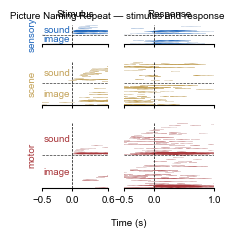

In [13]:
plot_cluster_phase_heatmap(
    repeat,
    "pn_repeat_cluster_stim_response_heatmap.svg",
    "Picture Naming Repeat — stimulus and response",
    phases=("stimulus", "response"),
)


## Stimulus only (the cross-modality test)

Same Repeat data, stimulus column enlarged. This is the panel that would
thicken Figure 2 if the dissociation holds.


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_stimulus_image_sound.svg


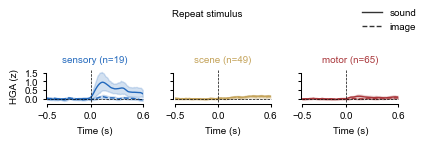

In [14]:
fig, axes = plt.subplots(
    1,
    len(CLUSTERS),
    figsize=(3.6 * len(CLUSTERS) * cm, 3.4 * cm),
    sharey=True,
)
lo, hi = TRACE_XLIMS["stimulus"]
stim = repeat[
    (repeat.phase == "stimulus") & (repeat.time >= lo) & (repeat.time <= hi)
]
for ax, cluster in zip(axes, CLUSTERS):
    color = FUNCTION_COLORS[cluster]
    for modality in MODALITIES:
        sns.lineplot(
            data=stim[stim.functional_cluster.eq(cluster) & stim.modality.eq(modality)],
            x="time",
            y="value",
            ax=ax,
            color=color,
            linestyle=MODALITY_LINESTYLES[modality],
            lw=1,
            errorbar=("ci", 95),
            legend=False,
        )
    ax.set_xlim(lo, hi)
    ax.set_xticks(TRACE_XTICKS["stimulus"])
    ax.set_title(
        f"{DISPLAY_LABELS[cluster]} ({n_label(stim[stim.functional_cluster.eq(cluster)])})",
        fontsize=fontsize,
        color=color,
    )
    ax.set_xlabel("Time (s)", fontsize=fontsize)
    ax.set_ylabel("HGA (z)" if ax is axes[0] else "", fontsize=fontsize)
    style_ax(ax)

handles = [
    Line2D(
        [0],
        [0],
        color="0.2",
        lw=1,
        linestyle=MODALITY_LINESTYLES[modality],
        label=modality,
    )
    for modality in MODALITIES
]
fig.legend(handles=handles, loc="upper right", fontsize=fontsize, frameon=False)
fig.suptitle("Repeat stimulus", fontsize=fontsize, y=1.05)
fig.tight_layout()
print("wrote", save_panel(fig, "pn_repeat_stimulus_image_sound.svg"))
plt.show()


## Electrode-level stimulus window

Mean HGA in `[0, 0.5)` s after stimulus onset, Repeat, paired image vs sound
on the same channel. Points above the diagonal prefer pictures; below prefer
sound. Wilcoxon is two-sided on the paired difference.


paired electrodes 133 {'sensory': 19, 'sustain': 49, 'motor': 65}


,cluster,display,n,median_sound,median_image,median_image_minus_sound,wilcoxon_image_vs_sound_p,wilcoxon_image_gt_0_p,W
0,sensory,sensory,19,0.207936,0.008717,-0.245824,0.000011,0.339714,2.0
1,sustain,scene,49,0.062680,0.067503,-0.024634,0.101065,0.001779,447.0
2,motor,motor,65,0.007746,0.001419,0.006247,0.511335,0.329567,972.0


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_stimulus_paired_scatter.svg


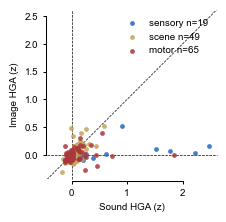

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 38.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_stimulus_delta_swarm.svg


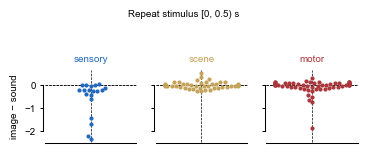

In [15]:
stim_means = window_means(repeat, phase="stimulus", window=STIM_WINDOW)
wide = paired_modalities(stim_means)
print(
    "paired electrodes",
    len(wide),
    wide.groupby("functional_cluster").size().reindex(CLUSTERS).to_dict(),
)

stats_rows = []
for cluster in CLUSTERS:
    g = wide.loc[wide.functional_cluster == cluster]
    if len(g) < 3:
        stat = p = p_img = np.nan
    else:
        stat, p = wilcoxon(g["image"], g["sound"], alternative="two-sided", zero_method="wilcox")
        _, p_img = wilcoxon(g["image"], alternative="greater", zero_method="wilcox")
    stats_rows.append(
        {
            "cluster": cluster,
            "display": DISPLAY_LABELS[cluster],
            "n": int(len(g)),
            "median_sound": g["sound"].median() if len(g) else np.nan,
            "median_image": g["image"].median() if len(g) else np.nan,
            "median_image_minus_sound": g["delta"].median() if len(g) else np.nan,
            "wilcoxon_image_vs_sound_p": p,
            "wilcoxon_image_gt_0_p": p_img,
            "W": stat,
        }
    )
stats = pd.DataFrame(stats_rows)
display(stats)

fig, ax = plt.subplots(figsize=(5.6 * cm, 5.6 * cm))
lim_lo = min(wide["sound"].min(), wide["image"].min())
lim_hi = max(wide["sound"].max(), wide["image"].max())
pad = 0.05 * (lim_hi - lim_lo if lim_hi > lim_lo else 1.0)
lims = (lim_lo - pad, lim_hi + pad)
ax.plot(lims, lims, color="k", lw=0.5, ls="--")
for cluster in CLUSTERS:
    g = wide.loc[wide.functional_cluster == cluster]
    ax.scatter(
        g["sound"],
        g["image"],
        s=12,
        c=FUNCTION_COLORS[cluster],
        label=f"{DISPLAY_LABELS[cluster]} n={len(g)}",
        linewidths=0,
        alpha=0.85,
        zorder=3,
    )
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Sound HGA (z)", fontsize=fontsize)
ax.set_ylabel("Image HGA (z)", fontsize=fontsize)
ax.legend(fontsize=fontsize, frameon=False)
style_ax(ax)
print("wrote", save_panel(fig, "pn_repeat_stimulus_paired_scatter.svg"))
plt.show()

fig, axes = plt.subplots(1, len(CLUSTERS), figsize=(3.2 * len(CLUSTERS) * cm, 3.6 * cm), sharey=True)
for ax, cluster in zip(axes, CLUSTERS):
    g = wide.loc[wide.functional_cluster == cluster]
    color = FUNCTION_COLORS[cluster]
    sns.swarmplot(y=g["delta"], ax=ax, color=color, size=3, linewidth=0)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_title(DISPLAY_LABELS[cluster], fontsize=fontsize, color=color)
    ax.set_xlabel("")
    ax.set_ylabel("image − sound" if ax is axes[0] else "", fontsize=fontsize)
    ax.set_xticks([])
    style_ax(ax)
fig.suptitle("Repeat stimulus [0, 0.5) s", fontsize=fontsize, y=1.04)
fig.tight_layout()
print("wrote", save_panel(fig, "pn_repeat_stimulus_delta_swarm.svg"))
plt.show()


## Stimulus difference trace (image − sound)

Paired at each time sample on channels present in both modalities. Positive
means pictures > sound.


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_stimulus_image_minus_sound.svg


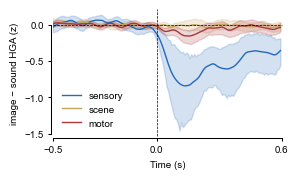

In [16]:
stim = repeat[repeat.phase == "stimulus"].copy()
sound = stim[stim.modality == "sound"].set_index(["channel", "time"])["value"]
image = stim[stim.modality == "image"].set_index(["channel", "time"])["value"]
common = sound.index.intersection(image.index)
delta = (image.loc[common] - sound.loc[common]).rename("value").reset_index()
delta = delta.merge(
    assignments[["channel", "functional_cluster"]].drop_duplicates(),
    on="channel",
    how="left",
)
delta = delta[delta.functional_cluster.isin(CLUSTERS)].copy()
delta["cluster_label"] = delta["functional_cluster"].map(DISPLAY_LABELS)

lo, hi = TRACE_XLIMS["stimulus"]
fig, ax = plt.subplots(figsize=(7.5 * cm, 4.2 * cm))
for cluster in CLUSTERS:
    sns.lineplot(
        data=delta[
            delta.functional_cluster.eq(cluster)
            & (delta.time >= lo)
            & (delta.time <= hi)
        ],
        x="time",
        y="value",
        ax=ax,
        color=FUNCTION_COLORS[cluster],
        lw=1,
        errorbar=("ci", 95),
        label=DISPLAY_LABELS[cluster],
    )
ax.set_xlim(lo, hi)
ax.set_xticks(TRACE_XTICKS["stimulus"])
ax.set_xlabel("Time (s)", fontsize=fontsize)
ax.set_ylabel("image − sound HGA (z)", fontsize=fontsize)
ax.legend(fontsize=fontsize, frameon=False)
style_ax(ax)
print("wrote", save_panel(fig, "pn_repeat_stimulus_image_minus_sound.svg"))
plt.show()


## Passive control

Same frozen electrodes, no vocal response. If scene still rises to pictures
in Passive, the picture response is not just naming. Sensory should remain
flat on image.


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_passive_stimulus_image_sound.svg


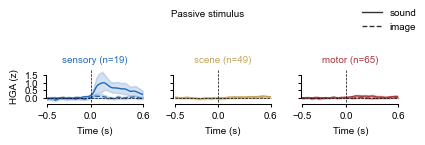

wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_passive_cluster_phase_image_sound.svg


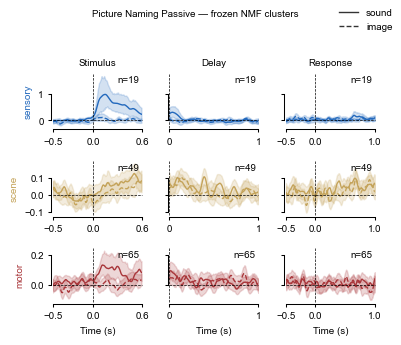

In [17]:
fig, axes = plt.subplots(
    1,
    len(CLUSTERS),
    figsize=(3.6 * len(CLUSTERS) * cm, 3.4 * cm),
    sharey=True,
)
lo, hi = TRACE_XLIMS["stimulus"]
stim = passive[
    (passive.phase == "stimulus") & (passive.time >= lo) & (passive.time <= hi)
]
for ax, cluster in zip(axes, CLUSTERS):
    color = FUNCTION_COLORS[cluster]
    for modality in MODALITIES:
        sns.lineplot(
            data=stim[stim.functional_cluster.eq(cluster) & stim.modality.eq(modality)],
            x="time",
            y="value",
            ax=ax,
            color=color,
            linestyle=MODALITY_LINESTYLES[modality],
            lw=1,
            errorbar=("ci", 95),
            legend=False,
        )
    ax.set_xlim(lo, hi)
    ax.set_xticks(TRACE_XTICKS["stimulus"])
    ax.set_title(
        f"{DISPLAY_LABELS[cluster]} ({n_label(stim[stim.functional_cluster.eq(cluster)])})",
        fontsize=fontsize,
        color=color,
    )
    ax.set_xlabel("Time (s)", fontsize=fontsize)
    ax.set_ylabel("HGA (z)" if ax is axes[0] else "", fontsize=fontsize)
    style_ax(ax)

handles = [
    Line2D(
        [0],
        [0],
        color="0.2",
        lw=1,
        linestyle=MODALITY_LINESTYLES[modality],
        label=modality,
    )
    for modality in MODALITIES
]
fig.legend(handles=handles, loc="upper right", fontsize=fontsize, frameon=False)
fig.suptitle("Passive stimulus", fontsize=fontsize, y=1.05)
fig.tight_layout()
print("wrote", save_panel(fig, "pn_passive_stimulus_image_sound.svg"))
plt.show()

plot_cluster_phase_grid(
    passive,
    "pn_passive_cluster_phase_image_sound.svg",
    "Picture Naming Passive — frozen NMF clusters",
)


## Fig 2-style spatial: sound vs image stimulus

Same insula mesh / NMF colors as Figure 2. Picture Naming Repeat, stimulus `[0, 0.6]` s:

1. Top: packaged-significant during **sound**.
2. Bottom: packaged-significant during **image**.

The next cell builds the channel sets. The cell after that is the 3D render
(PyVista / `mne.viz.Brain`). Run both on a compute node in `ieeg`.


In [18]:
STIM_SIG_WINDOW = (0.0, 0.6)


def _glob_pn_hga(proc: str, recording: str):
    pattern = f"sub-*/HGA/*_proc-{proc}_recording-{recording}_desc-Repeat_time.csv"
    return sorted(hga_results_dir(TASK).glob(pattern))


def significant_channels(proc: str, recording: str, t0: float, t1: float, wanted: set[str]) -> set[str]:
    hits = set()
    for path in _glob_pn_hga(proc, recording):
        subj = path.parent.parent.name.removeprefix("sub-")
        if subj in EXCLUDE_SUBJECTS:
            continue
        df = pd.read_csv(path, usecols=["channel", "time", "mask"])
        df["mask"] = df["mask"].astype(bool)
        keep = (
            df["channel"].isin(wanted)
            & (df["time"] >= t0)
            & (df["time"] <= t1)
            & df["mask"]
        )
        hits.update(df.loc[keep, "channel"].astype(str))
    return hits


wanted = set(assignments["channel"].astype(str))
image_stim = significant_channels("Stimulus", "image", *STIM_SIG_WINDOW, wanted)
sound_stim = significant_channels("Stimulus", "sound", *STIM_SIG_WINDOW, wanted)
pn_spatial_sets = {
    "sound_stimulus": sound_stim,
    "image_stimulus": image_stim,
}

rows = []
for name, channels in pn_spatial_sets.items():
    sub = assignments[assignments["channel"].isin(channels)]
    counts = sub.groupby("functional_cluster")["channel"].nunique()
    row = {"set": name, "n": int(sub["channel"].nunique())}
    for cluster in CLUSTERS:
        row[cluster] = int(counts.get(cluster, 0))
    rows.append(row)
spatial_counts = pd.DataFrame(rows)
display(spatial_counts)

members = assignments[
    ["channel", "subject", "roi", "hemi", "x", "y", "z", "functional_cluster"]
].copy()
for name, channels in pn_spatial_sets.items():
    members[name] = members["channel"].isin(channels)
keep = members[list(pn_spatial_sets)].any(axis=1)
members = members.loc[keep].sort_values(["functional_cluster", "channel"])
spatial_counts.to_csv(IMG_DIR / "pn_repeat_sound_vs_image_spatial_counts.csv", index=False)
members.to_csv(IMG_DIR / "pn_repeat_sound_vs_image_spatial_channels.csv", index=False)
print("wrote", IMG_DIR / "pn_repeat_sound_vs_image_spatial_counts.csv")
print("wrote", IMG_DIR / "pn_repeat_sound_vs_image_spatial_channels.csv")


,set,n,sensory,sustain,motor
0,sound_stimulus,57,16,24,17
1,image_stimulus,26,1,16,9


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_sound_vs_image_spatial_counts.csv
wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_sound_vs_image_spatial_channels.csv


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-09-21 10:14:53.053 ( 214.031s) [    7FE540366740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/picture_naming_modality/pn_repeat_sound_vs_image_spatial.svg


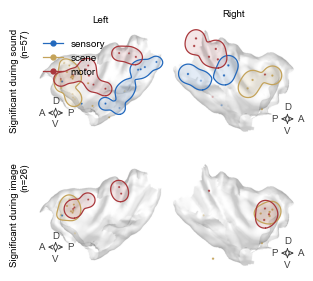

In [19]:
import os
import warnings

import pyvista as pv
from matplotlib.path import Path as MplPath
from mne.viz import Brain
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
template = "cvs_avg35_inMNI152"
insula_patterns = (
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
)
POINT_SIZE = 10.0
KDE_BANDWIDTH_PX = 25.0
KDE_LEVEL_FRAC = 0.18
KDE_FILL_ALPHA = 0.12
KDE_MIN_POINTS = 2
CROP_PAD_PX = 24
INSULA_COLOR = (0.9, 0.9, 0.9)
INSULA_LABEL_ALPHA = 0.55

labels = mne.read_labels_from_annot(
    subject=template,
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
lh_pial_coords, lh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/lh.pial")
rh_pial_coords, rh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_vertices(hemi: str) -> np.ndarray:
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f"No insula labels for {hemi}")
    return np.unique(verts)


def _faces_to_polydata(coords, faces) -> pv.PolyData:
    faces_pv = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), np.asarray(faces, dtype=np.int64)]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def insula_mesh(hemi: str, pial: np.ndarray, faces: np.ndarray):
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    mesh = _faces_to_polydata(pial, faces[keep])
    center = pial[verts].mean(axis=0)
    return mesh, center


lh_insula, lh_insula_center = insula_mesh("lh", lh_pial_coords, lh_faces)
rh_insula, rh_insula_center = insula_mesh("rh", rh_pial_coords, rh_faces)


def snap_to_pial(coords, tree, pial):
    _, idx = tree.query(coords)
    return pial[idx]


def add_cluster_spheres(brain, coords, clusters, tree, pial, keep_mask=None):
    coords = np.asarray(coords, dtype=float)
    if coords.size == 0:
        return np.zeros((0, 3), dtype=float)
    snapped = snap_to_pial(coords, tree, pial)
    if keep_mask is None:
        keep_mask = np.ones(len(coords), dtype=bool)
    keep_mask = np.asarray(keep_mask, dtype=bool)
    for cluster in CLUSTERS:
        mask = (np.asarray(clusters) == cluster) & keep_mask
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(snapped[mask], dtype=float))
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=POINT_SIZE,
            color=FUNCTION_COLORS[cluster],
            lighting=False,
        )
    return snapped


def project_xy(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if hasattr(plotter, "project_points_to_pixels"):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    h = int(image_shape[0])
    xy[:, 1] = (h - 1) - xy[:, 1]
    return xy


def _keep_ring(ring, pts) -> bool:
    if len(pts) < KDE_MIN_POINTS:
        return False
    return int(MplPath(np.asarray(ring, dtype=float)).contains_points(pts).sum()) >= KDE_MIN_POINTS


def kde_contour_rings(xy, image_shape, *, bandwidth_px=KDE_BANDWIDTH_PX, level_frac=KDE_LEVEL_FRAC):
    pts = np.asarray(xy, dtype=float)
    if len(pts) < 3:
        return []
    h, w = int(image_shape[0]), int(image_shape[1])
    dens = np.zeros((h, w), dtype=float)
    xs = np.clip(np.round(pts[:, 0]).astype(int), 0, w - 1)
    ys = np.clip(np.round(pts[:, 1]).astype(int), 0, h - 1)
    for x, y in zip(xs, ys):
        dens[y, x] += 1.0
    dens = gaussian_filter(dens, sigma=float(bandwidth_px))
    peak = float(dens.max())
    if peak <= 0:
        return []
    level = peak * float(level_frac)
    try:
        from skimage.measure import find_contours

        contours = find_contours(dens, level=level)
        rings = []
        for cont in contours:
            if len(cont) < 8:
                continue
            ring = np.column_stack([cont[:, 1], cont[:, 0]])
            ring = np.vstack([ring, ring[0]])
            if _keep_ring(ring, pts):
                rings.append(ring)
        return rings
    except ImportError:
        fig_c, ax_c = plt.subplots()
        yy, xx = np.mgrid[0:h, 0:w]
        cs = ax_c.contour(xx, yy, dens, levels=[level])
        rings = []
        for segs in cs.allsegs:
            for seg in segs:
                if len(seg) < 8:
                    continue
                ring = np.vstack([seg, seg[0]])
                if _keep_ring(ring, pts):
                    rings.append(ring)
        plt.close(fig_c)
        return rings


def draw_rings(ax, rings, color):
    for ring in rings:
        ax.fill(ring[:, 0], ring[:, 1], color=color, alpha=KDE_FILL_ALPHA, linewidth=0, zorder=3)
        ax.plot(
            ring[:, 0],
            ring[:, 1],
            color=color,
            linewidth=0.9,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=4,
        )


def draw_ap_dv(ax, *, anterior_is_left: bool, corner: str):
    if corner == "lower left":
        x0, y0, arm = 0.16, 0.18, 0.08
    else:
        x0, y0, arm = 0.91, 0.16, 0.07
    gap = 0.012
    if anterior_is_left:
        tips = {"A": (x0 - arm, y0), "P": (x0 + arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    else:
        tips = {"A": (x0 + arm, y0), "P": (x0 - arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    for label, (tx, ty) in tips.items():
        sx = x0 + gap * np.sign(tx - x0) if tx != x0 else x0
        sy = y0 + gap * np.sign(ty - y0) if ty != y0 else y0
        ax.annotate(
            "",
            xy=(tx, ty),
            xytext=(sx, sy),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="0.25", lw=0.7, mutation_scale=7),
            annotation_clip=False,
        )
        px = 0.03 * np.sign(tx - x0) if tx != x0 else 0.0
        py = 0.035 * np.sign(ty - y0) if ty != y0 else 0.0
        ax.text(
            tx + px,
            ty + py,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="0.25",
            clip_on=False,
        )


def crop_to_content(img, xy, pad=CROP_PAD_PX):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float)
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    return rgb[y0:y1, x0:x1], xy_c


def render_hemi(hemi: str, coords, clusters, sphere_mask=None):
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=INSULA_COLOR,
        alpha=0.0,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    mesh = lh_insula if hemi == "lh" else rh_insula
    plotter.add_mesh(
        mesh,
        color=INSULA_COLOR,
        opacity=INSULA_LABEL_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    tree = lh_tree if hemi == "lh" else rh_tree
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    snapped = add_cluster_spheres(brain, coords, clusters, tree, pial, keep_mask=sphere_mask)
    center = lh_insula_center if hemi == "lh" else rh_insula_center
    az = 180 if hemi == "lh" else 0
    brain.show_view(azimuth=az, elevation=90, distance=180, focalpoint=center)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    xy = project_xy(plotter, snapped, img.shape[:2])
    brain.close()
    return img, xy


spatial = assignments.loc[
    assignments["functional_cluster"].isin(CLUSTERS)
    & assignments[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
channels = spatial["channel"].to_numpy()
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0
rows = (
    ("sound_stimulus", "Significant during sound"),
    ("image_stimulus", "Significant during image"),
)

fig, axes = plt.subplots(2, 2, figsize=(8 * cm, 7.2 * cm))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for row_i, (set_name, row_title) in enumerate(rows):
        keep = np.isin(channels, list(pn_spatial_sets[set_name]))
        n_row = int(keep.sum())
        for col_i, (hemi, hemi_mask, title) in enumerate(
            (("lh", mask_lh, "Left"), ("rh", mask_rh, "Right"))
        ):
            img, xy = render_hemi(
                hemi,
                cord[hemi_mask],
                clust[hemi_mask],
                sphere_mask=keep[hemi_mask],
            )
            img, xy = crop_to_content(img, xy)
            ax = axes[row_i, col_i]
            ax.imshow(img)
            ax.set_xlim(0, img.shape[1])
            ax.set_ylim(img.shape[0], 0)
            ax.axis("off")
            if row_i == 0:
                ax.set_title(title, fontsize=fontsize)
            in_frame = (
                (xy[:, 0] >= 0)
                & (xy[:, 0] < img.shape[1])
                & (xy[:, 1] >= 0)
                & (xy[:, 1] < img.shape[0])
            )
            shown = keep[hemi_mask]
            for cluster in CLUSTERS:
                pts = xy[in_frame & shown & (np.asarray(clust[hemi_mask]) == cluster)]
                draw_rings(
                    ax,
                    kde_contour_rings(pts, img.shape[:2], bandwidth_px=KDE_BANDWIDTH_PX),
                    FUNCTION_COLORS[cluster],
                )
            if title == "Left":
                draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
                ax.text(
                    -0.04,
                    0.5,
                    f"{row_title}\n(n={n_row})",
                    transform=ax.transAxes,
                    rotation=90,
                    ha="right",
                    va="center",
                    fontsize=fontsize,
                )
            else:
                draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

handles = [
    Line2D(
        [0],
        [0],
        color=FUNCTION_COLORS[cluster],
        linewidth=0.9,
        marker="o",
        markersize=3.5,
        label=DISPLAY_LABELS[cluster],
    )
    for cluster in CLUSTERS
]
axes[0, 0].legend(handles=handles, frameon=False, fontsize=fontsize, loc="upper left")
fig.subplots_adjust(wspace=0.02, hspace=0.06, left=0.14, right=0.98, top=0.94, bottom=0.02)
print("wrote", save_panel(fig, "pn_repeat_sound_vs_image_spatial.svg", aligned=True))
plt.show()


## What to look for

If the memory holds:

1. **Sensory / sound** has an early stimulus peak; **sensory / image** stays
   near baseline. Paired points sit below the diagonal; `image − sound < 0`.
2. **Scene / image** still rises in stimulus (and maybe delay). Passive image
   should not go to zero if this is scene/AIC rather than naming-only.
3. **Motor** looks similar across modalities at response.

If sensory image is *not* flat, either the component is less auditory than
the NMF names imply, or the small PN sensory *n* is too noisy. If scene is
flat on image, the AIC/picture story does not survive this held-out modality.

A Figure 2 add-on, if this works, is the three-cluster Repeat stimulus overlay
(`pn_repeat_stimulus_image_sound.svg`), not another four-phase waveform strip.
